# Delhi Air Quality Forecasting — SIH26082 (v4)

Built on `delhi_master_dataset_v3.csv` with PM2.5, meteorological features, PM10/NO2/SO2/CO/O3, AQI and station coordinates.

**Improvements implemented in this version:**
1. PM2.5 direct forecasting extended to **72h** (1h/6h/12h/24h/72h).
2. Added **3-fold time-series cross-validation** on the training portion (no shuffling; final test set remains untouched).
3. Improved weather representation using cyclic wind-direction features.
4. Fixed the AQI alert target so missing future AQI is not incorrectly converted into class 0.
5. Removed future-looking interpolation/bfill; preprocessing now uses past-only short forward filling, with train-only median imputation inside modeling.

**Not included:** the previously discussed third improvement (LSTM/deep-learning model comparison).

*(Rename the uploaded file to `delhi_master_dataset_v3.csv`, or edit the path in the load cell, before running.)*


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor, XGBClassifier

pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid")


## 1. Load the multi-pollutant dataset

In [13]:
df = pd.read_csv("../data/delhi_master_dataset_v3.csv.xls")
print(df.shape)
df.head()

(16630, 48)


,datetime,location,latitude,longitude,pm25,hour,dow,hour_sin,hour_cos,dow_sin,dow_cos,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_rolling_mean_3h,pm25_rolling_mean_6h,pm25_rolling_mean_24h,pm25_rolling_std_6h,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,temperature_change_3h,ventilation_index,pm10,no2,so2,co,o3,pm25_avg,pm10_avg,no2_avg,so2_avg,co_avg,o3_avg,pm25_subindex,pm10_subindex,no2_subindex,so2_subindex,co_subindex,o3_subindex,aqi,dominant_pollutant,n_pollutants_available
0,2026-08-05 10:00:00,Air Check,28.623056,77.234167,62.7,10,2,5.000000e-01,-0.866025,0.974928,-0.222521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.3,69,4.7,310,976.1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2026-08-05 11:00:00,Air Check,28.623056,77.234167,56.8,11,2,2.588190e-01,-0.965926,0.974928,-0.222521,62.7,NaN,NaN,NaN,NaN,62.700000,NaN,NaN,NaN,31.6,71,3.6,300,976.2,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2026-08-05 12:00:00,Air Check,28.623056,77.234167,68.6,12,2,1.224647e-16,-1.000000,0.974928,-0.222521,56.8,NaN,NaN,NaN,NaN,59.750000,NaN,NaN,NaN,31.1,72,4.4,289,975.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2026-08-05 13:00:00,Air Check,28.623056,77.234167,71.5,13,2,-2.588190e-01,-0.965926,0.974928,-0.222521,68.6,62.7,NaN,NaN,NaN,62.700000,62.7,NaN,5.900000,31.9,69,5.0,300,974.7,0.0,0.6,5.600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2026-08-05 14:00:00,Air Check,28.623056,77.234167,69.9,14,2,-5.000000e-01,-0.866025,0.974928,-0.222521,71.5,56.8,NaN,NaN,NaN,65.633333,64.9,NaN,6.524314,31.8,68,5.7,294,973.7,0.0,0.2,5.928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [14]:
pollutant_cols = ["pm10", "no2", "so2", "co", "o3", "aqi"]
print(df[pollutant_cols + ["n_pollutants_available"]].isnull().mean().round(3))
print()
print(df["n_pollutants_available"].value_counts().sort_index())

pm10                      0.460
no2                       0.615
so2                       0.691
co                        0.614
o3                        0.576
aqi                       0.532
n_pollutants_available    0.000
dtype: float64

n_pollutants_available
0.0    1291
1.0    5465
2.0    2086
3.0    1811
4.0    1208
5.0    1243
6.0    3526
Name: count, dtype: int64


Most rows only have PM2.5 (`n_pollutants_available` is often 1), and NO2/SO2/CO/O3 are missing
50-70% of the time — most stations here are PM2.5-only monitors, only some report the full CAAQMS
pollutant suite. We keep this in mind: AQI/pollutant models below will train on a smaller, valid
subset of rows, not the full dataset — that's expected, not a bug.

## 2. Clean, sort, light gap-filling

Same as before for PM2.5 and weather (full linear interpolation — those are almost fully
populated). For the sparser pollutant columns we only fill **short gaps (≤3 hours)** — interpolating
across a 60-70%-missing series over long gaps would just be inventing data, not recovering it.
Longer gaps are left as NaN and simply excluded from that pollutant's training rows later.

In [15]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["location", "datetime"]).reset_index(drop=True)

weather_cols = [
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m", "wind_direction_10m",
    "surface_pressure", "precipitation", "temperature_change_3h", "ventilation_index",
]

# Forecasting-safe cleaning: never use future observations to fill the past.
# Only carry a previous value forward across short gaps (<=3 hours).
for c in ["pm25"] + weather_cols:
    df[c] = df.groupby("location")[c].transform(lambda x: x.ffill(limit=3))

# Sparse pollutants: fill only short gaps; leave long gaps as NaN.
for c in pollutant_cols:
    df[c] = df.groupby("location")[c].transform(lambda x: x.ffill(limit=3))

# Wind direction is circular, so 359° and 1° should be close to each other.
wind_rad = np.deg2rad(df["wind_direction_10m"])
df["wind_direction_sin"] = np.sin(wind_rad)
df["wind_direction_cos"] = np.cos(wind_rad)

print("Missing values after past-only gap filling:")
print(df[["pm25"] + weather_cols + ["wind_direction_sin", "wind_direction_cos"]].isnull().mean().round(3))


Missing values after past-only gap filling:
pm25                     0.045
temperature_2m           0.000
relative_humidity_2m     0.000
wind_speed_10m           0.000
wind_direction_10m       0.000
surface_pressure         0.000
precipitation            0.000
temperature_change_3h    0.004
ventilation_index        0.004
wind_direction_sin       0.000
wind_direction_cos       0.000
dtype: float64


## 3. Spatial features — what are neighbouring stations reading right now?

Pollution doesn't stay put — it drifts with wind between monitoring stations. For every
(station, timestamp) we compute an **inverse-distance-weighted average of all *other* stations'
PM2.5 and AQI at that same timestamp**. This is a legitimate real-time feature (no future leakage:
it's other stations' *current* readings, used to help forecast *this* station's *future* value),
and it's the "spatial/GIS" element the problem statement's tech stack calls for.

In [16]:
stations = df[["location", "latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
loc_list = stations["location"].tolist()
lat = stations["latitude"].to_numpy()
lon = stations["longitude"].to_numpy()

# Haversine distance matrix (km) between all station pairs
R = 6371.0
lat_r, lon_r = np.radians(lat), np.radians(lon)
dlat = lat_r[:, None] - lat_r[None, :]
dlon = lon_r[:, None] - lon_r[None, :]
a = np.sin(dlat / 2) ** 2 + np.cos(lat_r[:, None]) * np.cos(lat_r[None, :]) * np.sin(dlon / 2) ** 2
dist_km = 2 * R * np.arcsin(np.sqrt(a))

W = 1.0 / (dist_km + 1.0)   # +1 km avoids divide-by-zero and caps the closest-neighbour weight
np.fill_diagonal(W, 0.0)   # a station is not its own neighbour

def spatial_lag_feature(value_col):
    pivot = df.pivot(index="datetime", columns="location", values=value_col)[loc_list]
    mask = pivot.notna().to_numpy(dtype=float)
    values = pivot.fillna(0).to_numpy(dtype=float)
    numerator = values @ W.T
    denominator = mask @ W.T
    with np.errstate(invalid="ignore", divide="ignore"):
        lag = numerator / denominator
    lag_df = pd.DataFrame(lag, index=pivot.index, columns=loc_list).stack().rename(f"spatial_{value_col}_neighbors")
    lag_df.index.names = ["datetime", "location"]
    return lag_df.reset_index()

spatial_pm25 = spatial_lag_feature("pm25")
spatial_aqi = spatial_lag_feature("aqi")

df = df.merge(spatial_pm25, on=["datetime", "location"], how="left")
df = df.merge(spatial_aqi, on=["datetime", "location"], how="left")
print(df[["spatial_pm25_neighbors", "spatial_aqi_neighbors"]].isnull().mean().round(3))

spatial_pm25_neighbors    0.000
spatial_aqi_neighbors     0.128
dtype: float64


## 4. Map snapshot — pollution surface across Delhi-NCR

A quick visual sanity check: interpolate the 24 stations' PM2.5 readings at one timestamp into a
continuous surface over the Delhi-NCR area. This is the kind of view a real dashboard map layer
would show.

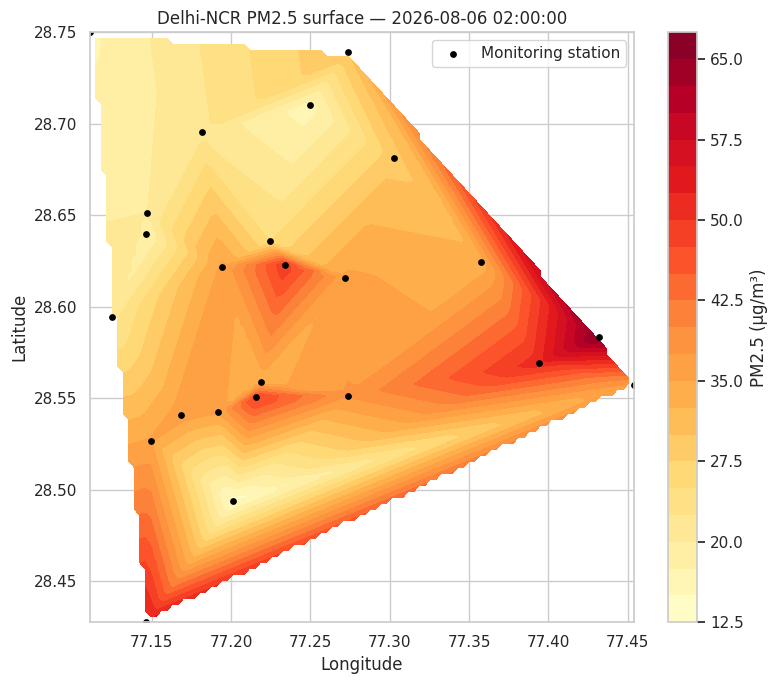

In [17]:
snapshot_time = df["datetime"].iloc[len(df) // 2]
snap = df[df["datetime"] == snapshot_time][["latitude", "longitude", "pm25"]].dropna()

grid_lat, grid_lon = np.mgrid[
    snap["latitude"].min():snap["latitude"].max():100j,
    snap["longitude"].min():snap["longitude"].max():100j,
]
grid_pm25 = griddata(
    (snap["latitude"], snap["longitude"]), snap["pm25"], (grid_lat, grid_lon), method="linear"
)

plt.figure(figsize=(8, 7))
plt.contourf(grid_lon, grid_lat, grid_pm25, levels=20, cmap="YlOrRd")
plt.colorbar(label="PM2.5 (µg/m³)")
plt.scatter(snap["longitude"], snap["latitude"], c="black", s=15, label="Monitoring station")
plt.title(f"Delhi-NCR PM2.5 surface — {snapshot_time}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Forecast targets — PM2.5 (multi-horizon) + AQI/pollutants (6h ahead)

PM2.5 keeps its four horizons (1h/6h/12h/24h) since it's well-populated. AQI and the individual
pollutants only get a 6h-ahead target — their smaller valid-row counts make multiple horizons
unnecessary to split further right now.

In [18]:
PM25_HORIZONS = {"1h": 1, "6h": 6, "12h": 12, "24h": 24, "72h": 72}
for name, h in PM25_HORIZONS.items():
    df[f"target_pm25_{name}"] = df.groupby("location")["pm25"].shift(-h)

OTHER_TARGETS = ["aqi", "pm10", "no2", "so2", "co", "o3"]
for c in OTHER_TARGETS:
    df[f"target_{c}_6h"] = df.groupby("location")[c].shift(-6)

valid_counts = {c: df[f"target_{c}_6h"].notna().sum() for c in OTHER_TARGETS}
print("PM2.5 target counts:")
print({h: int(df[f"target_pm25_{h}"].notna().sum()) for h in PM25_HORIZONS})
valid_counts


PM2.5 target counts:
{'1h': 15864, '6h': 15744, '12h': 15600, '24h': 15312, '72h': 14177}


{'aqi': np.int64(7830),
 'pm10': np.int64(8995),
 'no2': np.int64(6417),
 'so2': np.int64(5142),
 'co': np.int64(6429),
 'o3': np.int64(7064)}

## 6. Feature set (now including the spatial-lag features)

In [19]:
feature_cols = [
    "latitude", "longitude", "pm25",
    "pm25_lag_1h", "pm25_lag_3h", "pm25_lag_6h", "pm25_lag_12h", "pm25_lag_24h",
    "pm25_rolling_mean_3h", "pm25_rolling_mean_6h", "pm25_rolling_mean_24h", "pm25_rolling_std_6h",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m",
    "wind_direction_sin", "wind_direction_cos",
    "surface_pressure", "precipitation", "temperature_change_3h", "ventilation_index",
    "spatial_pm25_neighbors", "spatial_aqi_neighbors",
]

X_full = pd.get_dummies(df[feature_cols + ["location"]], columns=["location"], drop_first=True, dtype=int)
print("Feature matrix:", X_full.shape)


Feature matrix: (16630, 50)


## 7. Chronological split (same rule as v2 — never shuffle time series data)

In [20]:
cutoff_train = df["datetime"].quantile(0.70)
cutoff_val = df["datetime"].quantile(0.85)

train_mask = df["datetime"] <= cutoff_train
val_mask = (df["datetime"] > cutoff_train) & (df["datetime"] <= cutoff_val)
test_mask = df["datetime"] > cutoff_val

print("Train:", train_mask.sum(), " Val:", val_mask.sum(), " Test:", test_mask.sum())

Train: 11660  Val: 2496  Test: 2474


## 8. Train + evaluate: one reusable function for any target column

Used for PM2.5 (all 4 horizons) and now for AQI/PM10/NO2/SO2/CO/O3 (6h ahead) too. Baseline is
persistence ("value stays the same as now") wherever the current value is available for the test
rows, otherwise the train-set mean — the table below labels which baseline was used.

In [21]:
def make_xgb_regressor():
    return XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="mae",
    )

def train_eval(target_col, current_col=None):
    valid = df[target_col].notna()
    X = X_full.loc[valid]
    y = df.loc[valid, target_col]
    tr, va, te = train_mask[valid], val_mask[valid], test_mask[valid]

    # Learn imputation values from training rows only.
    train_median = X.loc[tr].median()
    X_imp = X.fillna(train_median)
    X_train, y_train = X_imp.loc[tr], y.loc[tr]
    X_val, y_val = X_imp.loc[va], y.loc[va]
    X_test, y_test = X_imp.loc[te], y.loc[te]

    model = make_xgb_regressor()
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred = model.predict(X_test)
    # import joblib, json, os
    # os.makedirs("../model", exist_ok=True)
    # joblib.dump(model, "../model/xgb_model.joblib")
    # print("✅ Model saved!")

    if current_col is not None and df.loc[X_test.index, current_col].notna().mean() > 0.5:
        baseline_pred = df.loc[X_test.index, current_col].fillna(df.loc[X_train.index, current_col].mean())
        baseline_name = "persistence"
    else:
        baseline_pred = pd.Series(y_train.mean(), index=y_test.index)
        baseline_name = "train-mean"

    return model, {
        "target": target_col,
        "n_test_rows": len(y_test),
        "model_mae": mean_absolute_error(y_test, pred),
        "model_rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "model_r2": r2_score(y_test, pred),
        "baseline": baseline_name,
        "baseline_mae": mean_absolute_error(y_test, baseline_pred),
        "baseline_rmse": np.sqrt(mean_squared_error(y_test, baseline_pred)),
    }

results = []
models = {}
# import joblib, json, os
# os.makedirs("../model", exist_ok=True)
# joblib.dump(models, "../model/xgb_model.joblib")
# print("✅ Model saved!")
for h in PM25_HORIZONS:
    m, r = train_eval(f"target_pm25_{h}", current_col="pm25")
    models[f"pm25_{h}"] = m
    results.append(r)

for c in OTHER_TARGETS:
    m, r = train_eval(f"target_{c}_6h", current_col=c)
    models[f"{c}_6h"] = m
    results.append(r)

results_df = pd.DataFrame(results)

import joblib, json, os
os.makedirs("../model", exist_ok=True)
joblib.dump(models, "../model/xgb_model.joblib")
print("✅ Model saved!")

# Save metadata
metadata = {
    "pm25_horizons": PM25_HORIZONS,
    "other_targets": OTHER_TARGETS,
    "feature_cols": feature_cols,
    "model_keys": list(models.keys()),
    "cutoff_train": str(cutoff_train),
    "cutoff_val": str(cutoff_val),
}

with open("../model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("✅ Metadata saved!")


models = joblib.load("../model/xgb_model.joblib")
with open("../model/metadata.json") as f:
    metadata = json.load(f)


✅ Model saved!
✅ Metadata saved!


## 8A. 3-fold time-series cross-validation (training data only)

This checks model stability across historical periods. `TimeSeriesSplit` keeps the order of time and never lets a later fold train an earlier period. The final test set is not used here.

In [22]:
# CV is run on the chronological training portion only.
pm25_cv_target = "target_pm25_6h"
valid_cv = df[pm25_cv_target].notna() & train_mask
X_cv = X_full.loc[valid_cv]
y_cv = df.loc[valid_cv, pm25_cv_target]

tscv = TimeSeriesSplit(n_splits=3)
cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_cv), start=1):
    X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
    y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]
    fold_median = X_tr.median()
    X_tr = X_tr.fillna(fold_median)
    X_va = X_va.fillna(fold_median)
    model_cv = make_xgb_regressor()
    model_cv.fit(X_tr, y_tr, verbose=False)
    p = model_cv.predict(X_va)
    cv_scores.append({
        "fold": fold,
        "MAE": mean_absolute_error(y_va, p),
        "RMSE": np.sqrt(mean_squared_error(y_va, p)),
        "R2": r2_score(y_va, p),
    })

cv_df = pd.DataFrame(cv_scores)
print(cv_df)
print("CV mean:")
print(cv_df[["MAE", "RMSE", "R2"]].mean().round(3))




   fold        MAE       RMSE        R2
0     1   9.936072  12.884316  0.266208
1     2  10.836655  14.511693  0.262504
2     3  12.796299  24.158641  0.284250
CV mean:
MAE     11.190
RMSE    17.185
R2       0.271
dtype: float64


imp = pd.Series(models["pm25_6h"].feature_importances_, index=X_full.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 7))
sns.barplot(x=imp.values, y=imp.index)
plt.title("Top 20 features — 6h-ahead PM2.5 model")
plt.xlabel("XGBoost importance")
plt.tight_layout()
plt.show()


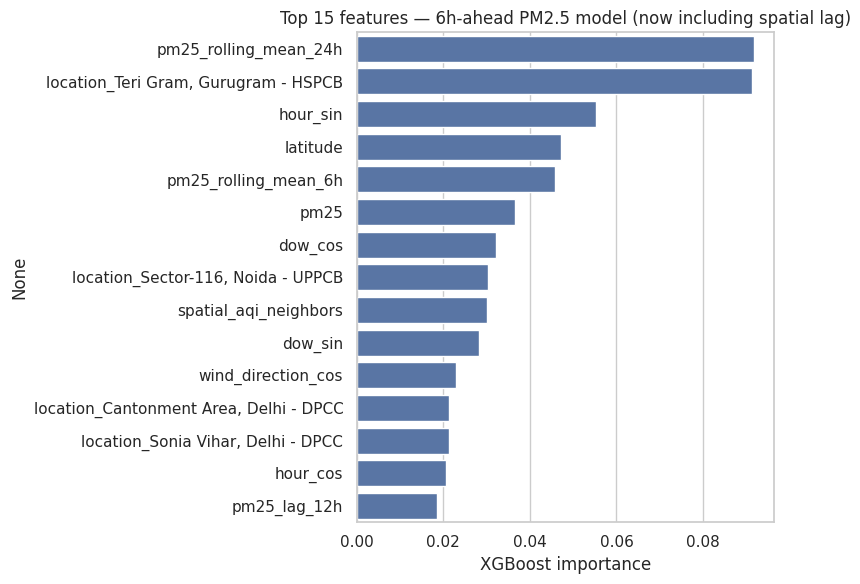

In [23]:
imp = pd.Series(models["pm25_6h"].feature_importances_, index=X_full.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index)
plt.title("Top 15 features — 6h-ahead PM2.5 model (now including spatial lag)")
plt.xlabel("XGBoost importance")
plt.tight_layout()
plt.show()

## 9. Severe-air-quality alert — now on the real official AQI

With actual CPCB AQI available, we can use an official category boundary instead of a made-up
percentile. CPCB bands: 0-50 Good, 51-100 Satisfactory, **101-200 Moderate**, 201-300 Poor,
301-400 Very Poor, 401-500 Severe.

In this (monsoon-only) data, AQI rarely exceeds 200 (only ~0.5% of rows), so "Poor"/"Severe" can't
be trained on yet. **AQI ≥ 100 — entering the "Moderate" band** — is the lowest official boundary
with enough positive examples (~21% of rows) to train a real classifier. Raise `AQI_ALERT_THRESHOLD`
to 200/300/400 once a full pollution season (with real Poor/Very Poor/Severe days) is available —
that's what should ship in the final dashboard.

In [24]:
AQI_ALERT_THRESHOLD = 100  # CPCB "Moderate" boundary; raise to 200/300/400 once winter data exists

future_aqi = df.groupby("location")["aqi"].shift(-6)
# Keep missing future AQI as missing; never convert it to class 0.
df["target_aqi_alert_6h"] = np.where(
    future_aqi.notna(),
    (future_aqi >= AQI_ALERT_THRESHOLD).astype(int),
    np.nan,
)

valid = df["target_aqi_alert_6h"].notna() & df["aqi"].notna()
Xc = X_full.loc[valid]
yc = df.loc[valid, "target_aqi_alert_6h"].astype(int)

tr, te = train_mask[valid], test_mask[valid]
train_median_c = Xc.loc[tr].median()
Xc = Xc.fillna(train_median_c)
X_train_c, y_train_c = Xc.loc[tr], yc.loc[tr]
X_test_c, y_test_c = Xc.loc[te], yc.loc[te]

print("Positive rate — train:", y_train_c.mean().round(3), " test:", y_test_c.mean().round(3))
pos_weight = (y_train_c == 0).sum() / max((y_train_c == 1).sum(), 1)

clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    scale_pos_weight=pos_weight, eval_metric="logloss",
)
clf.fit(X_train_c, y_train_c)
pred_c = clf.predict(X_test_c)

print(classification_report(y_test_c, pred_c, labels=[0, 1],
                             target_names=["below Moderate", "Moderate or worse"], zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test_c, pred_c, labels=[0, 1]))


Positive rate — train: 0.423  test: 0.575
                   precision    recall  f1-score   support

   below Moderate       0.74      0.87      0.80       370
Moderate or worse       0.89      0.78      0.83       501

         accuracy                           0.82       871
        macro avg       0.82      0.82      0.82       871
     weighted avg       0.83      0.82      0.82       871

Confusion matrix:
 [[322  48]
 [112 389]]


## 9A. How to interpret the final results

For each PM2.5 horizon, compare `model_mae` and `model_rmse` with the persistence baseline. For the alert classifier, focus on recall/F1 for the positive alert class rather than accuracy alone because alert events are rarer. Do not tune using the final test set.

## 10. What is covered now vs. still open

**Covered:**
- PM2.5 direct forecasts at **1h, 6h, 12h, 24h and 72h**.
- Meteorological coupling: temperature, humidity, wind speed/direction, pressure, precipitation, temperature trend and ventilation index.
- Circular wind-direction encoding using sin/cos.
- Spatial awareness using current neighbouring-station PM2.5/AQI readings.
- AQI + PM10/NO2/SO2/CO/O3 6h-ahead forecasting where data is available.
- CPCB-based AQI alert classification.
- Chronological train/validation/test split.
- 3-fold time-series cross-validation on the training portion.
- Past-only short-gap filling and train-only median imputation to reduce leakage.

**Still open:**
- Only about one month of mostly monsoon data: winter pollution episodes are needed to reliably learn Poor/Very Poor/Severe conditions and validate 72h forecasts.
- Dashboard/API deployment.
- LSTM/deep-learning model comparison is intentionally NOT added in this version.


In [25]:
# import joblib, json, os

# os.makedirs("ml/artifacts", exist_ok=True)

# # Save model
# joblib.dump(model, "../model/xgb_model.joblib")

# # Save metadata
# metadata = {
#     "feature_columns": X_train.columns.tolist(),
#     "imputation_medians": {col: float(X_train[col].median()) for col in X_train.columns},
#     "model_metrics": {
#         "r2": float(model.score(X_test, y_test)),
#         "mae": float(abs(model.predict(X_test) - y_test).mean()),
#         "rmse": float(((model.predict(X_test) - y_test) ** 2).mean() ** 0.5)
#     }
# }

# with open("../model/feature_metadata.json", 'w') as f:
#     json.dump(metadata, f)